In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MNE
import mne
from mne import io
from mne import Epochs

# Machine Learning
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from braindecode.models import EEGNetv4
import lightgbm as lgb

In [2]:
import torch
print(torch.__version__)
print("MPS available?", torch.backends.mps.is_available())

2.7.1
MPS available? True


### Config — paths & processing constants  

All hard-coded parameters live in one place so you (or a colleague) can
re-run the notebook on another machine by editing a single cell.

* **paths** – BIDS root and sub-folders inside `derivatives/`
* **data**  – recording constants reused later (montage, sfreq, etc.)

In [7]:
CONFIG = dict(
    paths = dict(
        bids_root   = Path("../bids_dataset"),
        annot_dir   = Path("../bids_dataset/derivatives/annotated/sub-lina/ses-02/eeg"),
    ),
    data = dict(
        sfreq       = 125.0,                      # Hz
        eeg_ch      = ["Fp1","Fp2","C3","C4","T7","T8",
                       "O1","O2","F3","F4","Fz","Pz","P3","P4"],
        n_blocks    = 21,
        selected_runs = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21],
    ),
    model = dict(
        cv_folds    = 5,            # number of StratifiedGroupKFold splits
    ),
)

# create necessary directories
for path in CONFIG["paths"].values():
    if path.suffix == "":  # skip CSV
        path.mkdir(parents=True, exist_ok=True)

print("Notebook-09 CONFIG defined and directories created 🚀")

Notebook-09 CONFIG defined and directories created 🚀


## 1. Dataset Structure

In this section, we load all annotated FIF blocks and verify the integrity and shape of the data. Each block is read from disk with its pre-processed channels and annotations, ensuring all expected blocks (0–19) are available and correctly formatted.

We check:

- That all blocks (0–19) are loaded with the correct number of channels and samples.
- The consistency of data shape and duration across blocks.

In [8]:
# Load only selected annotated EEG blocks into a dictionary
raws = {}
selected_runs = CONFIG['data']['selected_runs']

for block_id in selected_runs:
    fname = CONFIG['paths']['annot_dir'] / f'sub-lina_ses-02_task-musicphrases-sing_run-{block_id:02d}_icaclean_annot.fif'
    raws[block_id] = io.read_raw_fif(fname, preload=True, verbose='ERROR')
    data = raws[block_id].get_data()
    print(f"Loaded block {block_id:02d}: {data.shape[0]} channels × {data.shape[1]} samples, {raws[block_id].times[-1]:.2f} s")

# Quick check: all expected blocks loaded
assert set(raws.keys()) == set(selected_runs), "Mismatch in number of blocks loaded"

# Print a short summary for confirmation
print(f"\nSelected {len(raws)} blocks loaded. Example block keys: {list(raws.keys())[:4]}")


Loaded block 01: 15 channels × 16626 samples, 133.00 s
Loaded block 02: 15 channels × 16626 samples, 133.00 s
Loaded block 03: 15 channels × 16626 samples, 133.00 s
Loaded block 04: 15 channels × 16626 samples, 133.00 s
Loaded block 05: 15 channels × 16626 samples, 133.00 s
Loaded block 06: 15 channels × 16626 samples, 133.00 s
Loaded block 07: 15 channels × 16626 samples, 133.00 s
Loaded block 08: 15 channels × 16626 samples, 133.00 s
Loaded block 09: 15 channels × 16626 samples, 133.00 s
Loaded block 10: 15 channels × 16626 samples, 133.00 s
Loaded block 11: 15 channels × 16626 samples, 133.00 s
Loaded block 12: 15 channels × 16626 samples, 133.00 s
Loaded block 13: 15 channels × 16626 samples, 133.00 s
Loaded block 14: 15 channels × 16626 samples, 133.00 s
Loaded block 15: 15 channels × 16626 samples, 133.00 s
Loaded block 16: 15 channels × 16626 samples, 133.00 s
Loaded block 17: 15 channels × 16626 samples, 133.00 s
Loaded block 18: 15 channels × 16626 samples, 133.00 s
Loaded blo

In [17]:
eeg_ch_names = CONFIG['data']['eeg_ch']
bad_chs = {}
eeg_ch_names = [ch for ch in eeg_ch_names if ch not in bad_chs]

first_raw = next(iter(raws.values()))  # generic way to access the first loaded run
all_ch_names = first_raw.ch_names

eeg_picks = [all_ch_names.index(ch) for ch in eeg_ch_names]
n_channels = len(eeg_picks)

print("EEG picks:", eeg_picks)
print("EEG channel names:", [all_ch_names[i] for i in eeg_picks])
print("Number of EEG channels:", n_channels)


EEG picks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
EEG channel names: ['Fp1', 'Fp2', 'C3', 'C4', 'T7', 'T8', 'O1', 'O2', 'F3', 'F4', 'Fz', 'Pz', 'P3', 'P4']
Number of EEG channels: 14


In [18]:
# Inspect annotations from block 1
raw = next(iter(raws.values()))
annots = raw.annotations

print("Annotation descriptions:")
print(np.unique(annots.description))

print("\nFirst few annotations:")
for onset, duration, desc in zip(annots.onset[:10], annots.duration[:10], annots.description[:10]):
    print(f"Onset: {onset:.2f} s | Duration: {duration:.2f} s | Description: {desc}")


Annotation descriptions:
['phrase/0' 'phrase/1' 'phrase/2' 'phrase/3' 'phrase/4' 'phrase/5'
 'phrase/6']

First few annotations:
Onset: 25.55 s | Duration: 5.00 s | Description: phrase/0
Onset: 30.55 s | Duration: 5.00 s | Description: phrase/1
Onset: 35.55 s | Duration: 6.00 s | Description: phrase/2
Onset: 41.55 s | Duration: 7.00 s | Description: phrase/3
Onset: 48.55 s | Duration: 6.00 s | Description: phrase/4
Onset: 54.55 s | Duration: 6.00 s | Description: phrase/5
Onset: 60.55 s | Duration: 8.00 s | Description: phrase/6
Onset: 68.55 s | Duration: 6.00 s | Description: phrase/0
Onset: 74.55 s | Duration: 5.00 s | Description: phrase/1
Onset: 79.55 s | Duration: 6.00 s | Description: phrase/2


In [19]:
# Sliding Window Extraction

window_length_s = 2.0
window_hop_s = 0.5
sfreq = raw = next(iter(raws.values())).info['sfreq']
window_samples = int(window_length_s * sfreq)
window_hop_samples = int(window_hop_s * sfreq)

all_windows = []

for block_id, raw in raws.items():
    annots = raw.annotations
    onset_s = annots.onset
    duration_s = annots.duration
    desc = annots.description

    # Filter only valid phrase labels (excluding phrase/0)
    phrase_onsets = []
    phrase_labels = []
    for onset, label in zip(onset_s, desc):
        if label.startswith("phrase/"):
            phrase_num = int(label.split("/")[1])
            if phrase_num == 0:
                continue  # skip phrase/0
            phrase_onsets.append(onset)
            phrase_labels.append(phrase_num)

    phrase_onsets = np.array(phrase_onsets)
    phrase_labels = np.array(phrase_labels)

    # Generate sliding windows
    t_centers = np.arange(window_length_s/2, raw.times[-1] - window_length_s/2, window_hop_s)
    for t_center in t_centers:
        center_sample = int(t_center * sfreq)

        # Skip if no phrase label available at this time
        possible_idx = np.where(phrase_onsets <= t_center)[0]
        if len(possible_idx) == 0:
            continue
        phrase_idx = possible_idx[-1]
        label = phrase_labels[phrase_idx]

        # Compute window start (bounds check)
        t_start = t_center - window_length_s/2
        start_sample = int(t_start * sfreq)
        if start_sample < 0 or (start_sample + window_samples) > raw.n_times:
            continue

        all_windows.append({
            "block_id": block_id,
            "start_sample": start_sample,
            "center_sample": center_sample,
            "label": label,
            "t_center": t_center,
        })

# Check integrity
print("Checking window shapes...")
for w in all_windows:
    block_id = w['block_id']
    raw = raws[block_id]
    seg = raw.get_data(picks=eeg_picks, start=w['start_sample'], stop=w['start_sample'] + window_samples)
    if seg.shape != (len(eeg_picks), window_samples):
        print(f"Bad window: block {block_id}, start {w['start_sample']} (shape {seg.shape})")

windows_df = pd.DataFrame(all_windows)
print(f"Extracted {len(windows_df)} valid windows from {len(raws)} blocks.")
print(windows_df.head())


Checking window shapes...
Extracted 4216 valid windows from 21 blocks.
   block_id  start_sample  center_sample  label  t_center
0         1          3750           3875      1      31.0
1         1          3812           3937      1      31.5
2         1          3875           4000      1      32.0
3         1          3937           4062      1      32.5
4         1          4000           4125      1      33.0


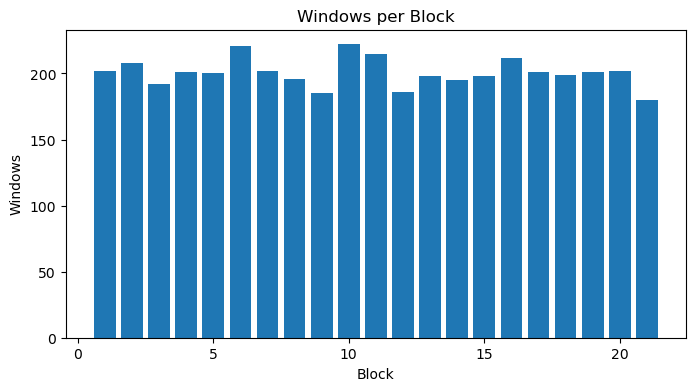

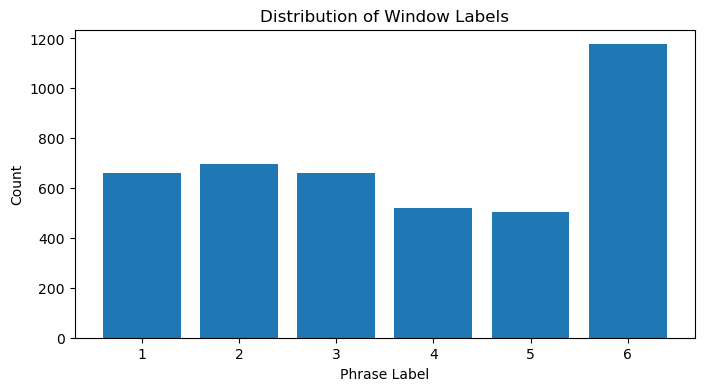

Window counts per block:
 block_id
1     202
2     208
3     192
4     201
5     200
6     221
7     202
8     196
9     185
10    222
11    215
12    186
13    198
14    195
15    198
16    212
17    201
18    199
19    201
20    202
21    180
Name: count, dtype: int64

Label distribution:
 label
1     659
2     698
3     659
4     520
5     504
6    1176
Name: count, dtype: int64


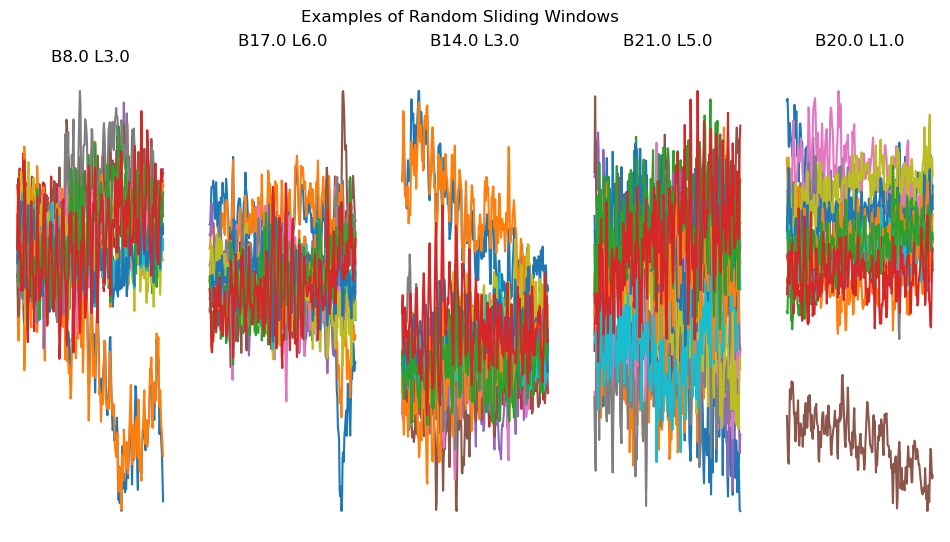

In [20]:
# 1.3. Window/Label Distribution Summary & Visual QC

# Distribution of windows per block
block_counts = windows_df['block_id'].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.bar(block_counts.index, block_counts.values)
plt.xlabel('Block')
plt.ylabel('Windows')
plt.title('Windows per Block')
plt.show()

# Distribution of labels
label_counts = windows_df['label'].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel('Phrase Label')
plt.ylabel('Count')
plt.title('Distribution of Window Labels')
plt.show()

print("Window counts per block:\n", block_counts)
print("\nLabel distribution:\n", label_counts)

# Quick plot of 5 random windows for QC
np.random.seed(42)
sample_idx = np.random.choice(len(windows_df), 5, replace=False)
plt.figure(figsize=(12,6))
for i, idx in enumerate(sample_idx, 1):
    row = windows_df.iloc[idx]
    block_id = row['block_id']
    start = row['start_sample']
    raw = raws[block_id]
    seg = raw.get_data(picks=eeg_picks, start=int(row['start_sample']), stop=int(row['start_sample']) + window_samples)
    plt.subplot(1,5,i)
    plt.plot(seg.T)
    plt.title(f"B{block_id} L{row['label']}")
    plt.axis('off')
plt.suptitle("Examples of Random Sliding Windows")
plt.show()

## 2. Labels and Groups

We extract sliding 2 s windows (with 0.5 s overlap) across each block, skipping intervals labeled as BAD_intro. For each window, the label is set to the most recent phrase marker preceding the window center.

We create a DataFrame indexing every window by:

- Block of origin (block_id)
- Window start and center (in samples and seconds)
- Assigned phrase label (1–6)

We confirm:

- The total number of windows and their distribution across blocks.
- The distribution of labels for quality control.

Counts of each label per block:
label   1   2   3   4   5   6
group                        
1      32  36  30  24  24  56
2      32  36  36  24  24  56
3      32  28  28  24  24  56
4      32  36  29  24  24  56
5      32  36  28  24  24  56
6      32  36  42  31  24  56
7      32  36  30  24  24  56
8      32  32  28  24  24  56
9      29  24  28  24  24  56
10     32  36  42  32  24  56
11     32  36  42  25  24  56
12     30  24  28  24  24  56
13     32  34  28  24  24  56
14     32  31  28  24  24  56
15     32  34  28  24  24  56
16     32  36  40  24  24  56
17     32  36  29  24  24  56
18     32  35  28  24  24  56
19     32  36  29  24  24  56
20     32  36  30  24  24  56
21     24  24  28  24  24  56


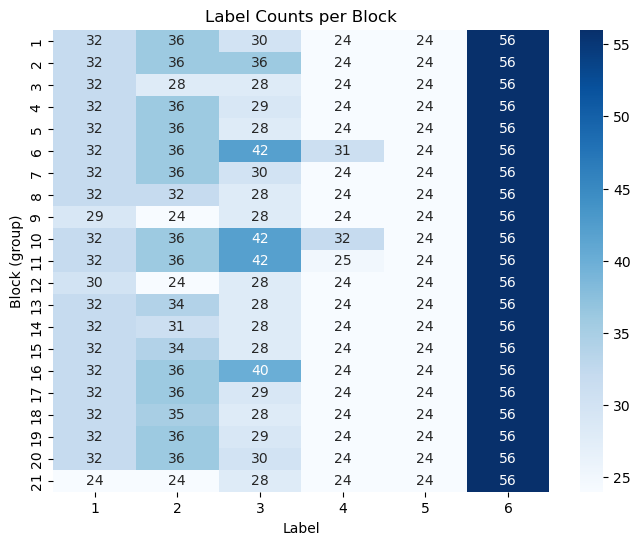

Number of missing (block, label) pairs: 0


In [21]:
# 2b. Confirming Labels and Groups

# Add a "group" column as an alias for block_id (for clarity)
windows_df["group"] = windows_df["block_id"]

# Table: counts of each label per group (block)
pivot = pd.pivot_table(windows_df, index="group", columns="label", aggfunc="size", fill_value=0)

print("Counts of each label per block:")
print(pivot)

# Visualize as heatmap (optional)
plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Label Counts per Block")
plt.xlabel("Label")
plt.ylabel("Block (group)")
plt.show()

# Quick assertion: all labels present in most blocks
n_missing = (pivot == 0).sum().sum()
print(f"Number of missing (block, label) pairs: {n_missing}")


## 3. Split Strategy

In this section, we use StratifiedGroupKFold to partition the extracted sliding windows into training, validation, and test splits. This strategy preserves the balance of phrase labels across splits while ensuring that all windows from a given block (recording session) remain grouped together. This is essential to avoid data leakage and to maintain a realistic out-of-sample evaluation.

We proceed as follows:

- The group column (block index) is used to keep all windows from the same block in a single split.
- The label column ensures each split maintains a similar class distribution.
- We assign split labels (train, val, test) to each window in the DataFrame for downstream processing.
- We visually inspect the label distribution within each split to verify balance and exclusivity.

This approach ensures robust, reproducible model evaluation without temporal or subject leakage.

Train blocks (10): [3, 4, 5, 11, 14, 15, 17, 19, 20, 21]
  Val blocks (6): [6, 7, 8, 10, 12, 13]
 Test blocks (5): [1, 2, 9, 16, 18]


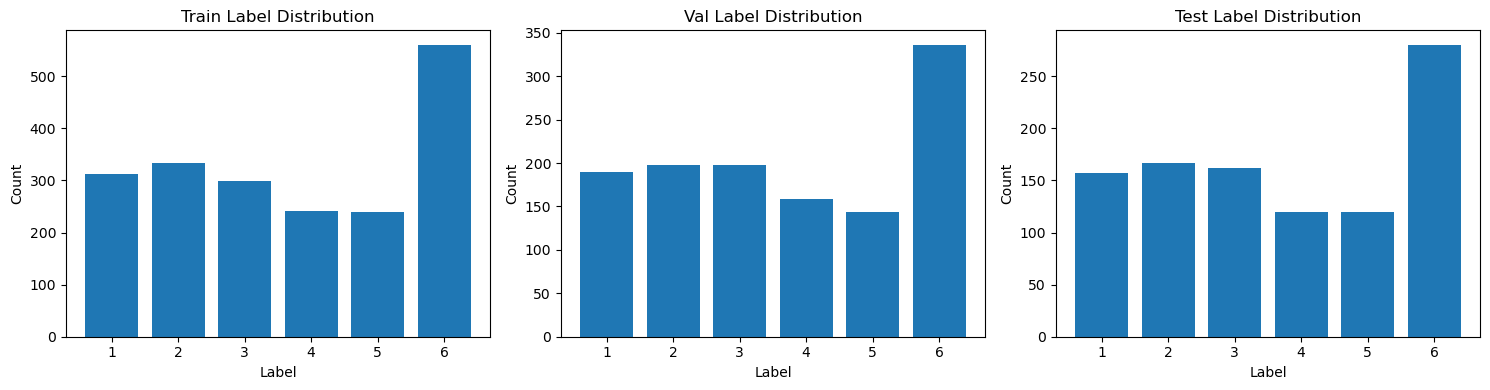

In [22]:
# 3. Split Strategy: GroupShuffleSplit (block_id como grupo)
from sklearn.model_selection import GroupShuffleSplit
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------
# a) Dados de entrada
# --------------------------------------------------------------------
y       = windows_df["label"].values
groups  = windows_df["group"].values       # group == block_id já criado antes
n_total = len(windows_df)

# --------------------------------------------------------------------
# b) 1º split → separa TESTE (20 % dos blocos)
# --------------------------------------------------------------------
gss_test = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=42)
trainval_idx, test_idx = next(gss_test.split(np.zeros(n_total), y, groups))

# --------------------------------------------------------------------
# c) 2º split → da parte de treino+val tira VALIDAÇÃO (20 % dos blocos remanescentes)
# --------------------------------------------------------------------
trainval_groups = groups[trainval_idx]
y_trainval      = y[trainval_idx]

gss_val = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=43)
train_idx, val_idx = next(gss_val.split(np.zeros(len(trainval_idx)), y_trainval, trainval_groups))

# --------------------------------------------------------------------
# d) Mapeia índices para rótulos textuais
# --------------------------------------------------------------------
# ------------- blocos de cada split -----------------
test_groups = set(windows_df.loc[test_idx, "group"])
val_groups  = set(windows_df.loc[val_idx,  "group"])
# tudo que sobrar é train
train_groups = set(windows_df["group"]) - test_groups - val_groups

# ------------- atribuição ---------------------------
windows_df["split"] = "train"
windows_df.loc[windows_df["group"].isin(val_groups),  "split"] = "val"
windows_df.loc[windows_df["group"].isin(test_groups), "split"] = "test"


# --------------------------------------------------------------------
# e) Confirma exclusividade de blocos
# --------------------------------------------------------------------
for s in ["train", "val", "test"]:
    blocks = sorted(set(windows_df.loc[windows_df.split == s, "group"]))
    print(f"{s.capitalize():>5} blocks ({len(blocks)}): {blocks}")

assert len(
    set.intersection(
        *[set(windows_df.loc[windows_df.split == s, "group"])
          for s in ["train", "val", "test"]]
    )
) == 0, "Block overlap detected!"

# --------------------------------------------------------------------
# f) Visualiza equilíbrio de rótulos por split
# --------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, ["train", "val", "test"]):
    counts = (windows_df[windows_df.split == split]["label"]
              .value_counts()
              .sort_index())
    ax.bar(counts.index, counts.values)
    ax.set_title(f"{split.capitalize()} Label Distribution")
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 4. Normalization (Z-Score)

In this section, we compute per-channel mean and standard deviation using only the training windows. We then apply a z-score normalization to all windows, using these training-derived parameters for the validation and test sets as well.

**Procedure:**

- Select only windows assigned to the train split from the DataFrame.
- For each training window, load the corresponding EEG segment and concatenate them across all training blocks.
- Compute the mean and standard deviation for each channel, resulting in one mean and one std per channel.
- Normalize each window (across all splits) by subtracting the training mean and dividing by the training std, channel-wise.

This approach ensures that no information from the validation or test sets "leaks" into the normalization parameters, preserving a fair model evaluation.

We check the resulting normalized values for correctness by inspecting their distributions.

In [23]:
print("Channel names:", next(iter(raws.values())).ch_names)
print("Channel types:", next(iter(raws.values())).get_channel_types())

Channel names: ['Fp1', 'Fp2', 'C3', 'C4', 'T7', 'T8', 'O1', 'O2', 'F3', 'F4', 'Fz', 'Pz', 'P3', 'P4', 'stim']
Channel types: ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'stim']


In [24]:
# eeg_picks = [i for i, t in enumerate(raws[0].get_channel_types()) if t == 'eeg']
print("EEG picks:", eeg_picks)
print("Number of EEG channels:", len(eeg_picks))

EEG picks: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Number of EEG channels: 14


In [25]:
# 4a. Compute Per-Channel Mean and Std on Training Windows

# Parameters
n_channels = len(eeg_picks)
window_samples = int(2.0 * sfreq)

# Select only train windows
train_df = windows_df[windows_df['split'] == 'train']

# Concatenate all training segments (channels x samples x windows)
train_segments = []
for i, row in train_df.iterrows():
    raw = raws[row['block_id']]
    seg = raw.get_data(picks=eeg_picks, start=int(row['start_sample']), stop=int(row['start_sample']) + window_samples)
    train_segments.append(seg)
train_data = np.stack(train_segments, axis=2)  # shape: channels x samples x windows

# Reshape to (channels, total_samples)
train_data_reshaped = train_data.reshape(n_channels, -1)

# Compute mean and std for each channel
channel_mean = train_data_reshaped.mean(axis=1)  # shape: (channels,)
channel_std = train_data_reshaped.std(axis=1)

print("Training set channel means:\n", channel_mean)
print("Training set channel stds:\n", channel_std)
print("Train data shape (channels x samples x windows):", train_data.shape)


Training set channel means:
 [ 2.28081675e-09  2.04149847e-09  5.85529576e-10  1.22392117e-11
 -1.35079874e-09  8.50288717e-10 -3.20776921e-09 -5.68363296e-10
  1.33047584e-09 -2.36407338e-10 -4.32724207e-10 -5.46427792e-10
 -4.02124972e-10 -3.56232970e-10]
Training set channel stds:
 [6.12531189e-07 5.30687609e-07 1.75410173e-07 1.83946851e-07
 2.56898177e-07 3.07834786e-07 2.79588079e-07 2.60971719e-07
 1.84871332e-07 1.54888446e-07 1.82994830e-07 2.28251977e-07
 2.24391668e-07 2.25079342e-07]
Train data shape (channels x samples x windows): (14, 250, 1985)


In [26]:
# 4b. Apply Z-Score Normalization to All Windows

# Function for quick normalization
def normalize_segment(seg, mean, std):
    # seg: shape channels x samples
    return (seg - mean[:, None]) / std[:, None]

# Example: apply normalization to the first five windows and print means/stds
for idx in range(5):
    row = windows_df.iloc[idx]
    raw = raws[row['block_id']]
    seg = raw.get_data(picks=eeg_picks, start=int(row['start_sample']), stop=int(row['start_sample']) + window_samples)
    seg_norm = normalize_segment(seg, channel_mean, channel_std)
    print(f"Window {idx}: mean (per channel) after norm: {seg_norm.mean(axis=1)}")
    print(f"Window {idx}: std (per channel) after norm: {seg_norm.std(axis=1)}")


Window 0: mean (per channel) after norm: [-0.55267752 -0.51394846 -0.49270099 -0.67346464  0.44094799  0.5513459
  0.17911352  1.28136833  1.5202521   0.58251581 -0.54642371  0.14687316
 -0.07417463 -0.59561006]
Window 0: std (per channel) after norm: [0.77952425 0.73678912 1.05678411 0.76469759 0.7512252  0.50434494
 0.58332947 0.58354519 0.73454852 0.73056613 0.59543596 0.97197504
 0.86560717 0.7198874 ]
Window 1: mean (per channel) after norm: [-0.80035987 -0.79585278 -0.02020276 -0.37913366  0.69904902  0.58271922
  0.15547888  1.37579741  1.14933672  0.52887809 -0.59580149  0.41147914
  0.21637808 -0.45958638]
Window 1: std (per channel) after norm: [0.71577834 0.6418578  0.91000141 0.79088231 0.6431203  0.49930727
 0.56569129 0.57013566 0.88813167 0.76014289 0.64933219 0.93660592
 0.81539433 0.81790856]
Window 2: mean (per channel) after norm: [-0.90521115 -0.83120384  0.30329684  0.00936827  0.7781725   0.58427169
 -0.00350628  1.28393569  0.43387978  0.53743817 -0.58280808  0.5

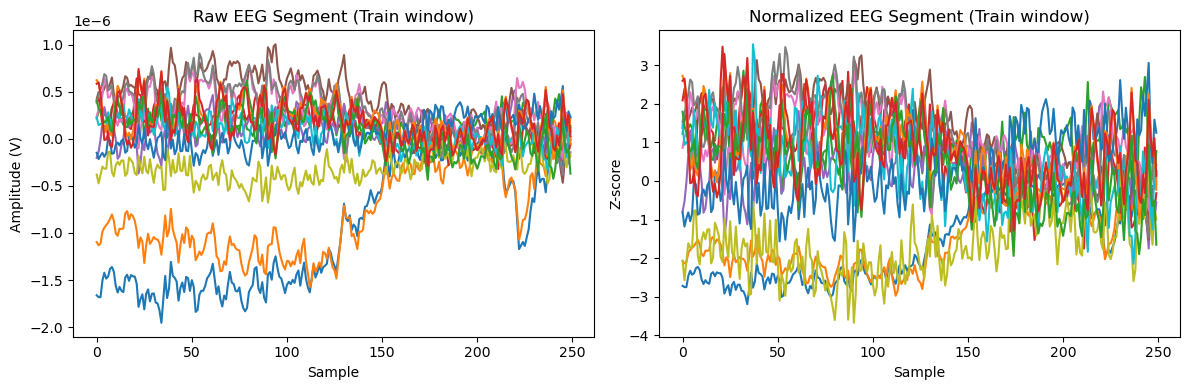

In [27]:
# 4c. Visual Check: Distribution Before/After Normalization

# Pick a random training window
rand_idx = train_df.sample(1, random_state=0).index[0]
row = windows_df.loc[rand_idx]
raw = raws[row['block_id']]
seg = raw.get_data(picks=eeg_picks, start=int(row['start_sample']), stop=int(row['start_sample']) + window_samples)
seg_norm = normalize_segment(seg, channel_mean, channel_std)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(seg.T)
plt.title("Raw EEG Segment (Train window)")
plt.xlabel("Sample")
plt.ylabel("Amplitude (V)")

plt.subplot(1,2,2)
plt.plot(seg_norm.T)
plt.title("Normalized EEG Segment (Train window)")
plt.xlabel("Sample")
plt.ylabel("Z-score")

plt.tight_layout()
plt.show()


## 5. Class Imbalance and Loss Weights

In this section, we address the natural class imbalance present in the dataset: some phrase labels are more frequent than others due to experimental design and windowing strategy.

To ensure that the model does not become biased toward the majority classes, we:

- Compute the frequency of each class in the training split only.
- Calculate inverse-frequency weights so that minority classes receive higher penalty during training.
- Pass these weights to the loss function (e.g., PyTorch’s CrossEntropyLoss), which amplifies the contribution of under-represented classes to the training objective.

We visualize:
- The distribution of class frequencies in the training set.
- The corresponding class weights derived for the loss function.

This approach helps balance the learning process and encourages the model to perform well on all classes, not just the most common ones.

In [28]:
# 5. Class Imbalance: Compute Class Weights
# Only use the train split!
train_labels = windows_df.loc[windows_df["split"] == "train", "label"].values

# Calculate class frequencies (labels should be 1-based)
classes, counts = np.unique(train_labels, return_counts=True)
print("Train set class frequencies:")
for c, n in zip(classes, counts):
    print(f"Label {c}: {n} windows")

# Compute inverse-frequency weights
freqs = counts / counts.sum()
inv_freq = 1.0 / freqs
class_weights = inv_freq / inv_freq.sum() * len(classes)  # Normalize so sum = n_classes

# Prepare weights tensor for CrossEntropyLoss (zero-based index)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)

print("Class weights (to use in CrossEntropyLoss):", class_weights)


Train set class frequencies:
Label 1: 312 windows
Label 2: 333 windows
Label 3: 299 windows
Label 4: 241 windows
Label 5: 240 windows
Label 6: 560 windows
Class weights (to use in CrossEntropyLoss): [0.97844743 0.91674354 1.02098863 1.26670373 1.27198166 0.545135  ]


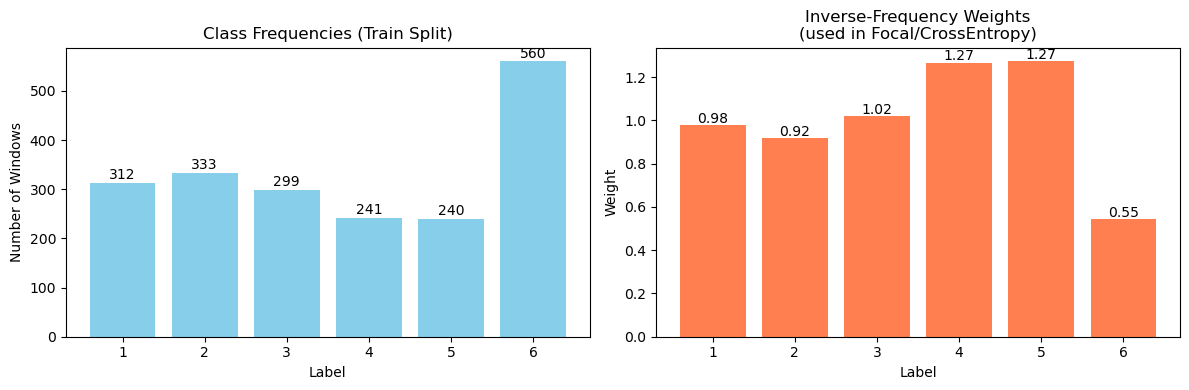

In [29]:
labels = [1, 2, 3, 4, 5, 6]
freqs = counts
weights = class_weights

fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Frequencies
axes[0].bar(labels, freqs, color='skyblue')
axes[0].set_title("Class Frequencies (Train Split)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Number of Windows")
for i, v in enumerate(freqs):
    axes[0].text(labels[i], v + 8, str(v), ha='center')

# Weights
axes[1].bar(labels, weights, color='coral')
axes[1].set_title("Inverse-Frequency Weights\n(used in Focal/CrossEntropy)")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Weight")
for i, w in enumerate(weights):
    axes[1].text(labels[i], w + 0.01, f"{w:.2f}", ha='center')

plt.tight_layout()
plt.show()


## 6. EEGNet Modeling Pipeline (PyTorch)

In this section, we prepare the EEG data for deep learning using PyTorch and define the EEGNet model.

**6.1. EEGWindowDataset**

We define a custom `Dataset` class that loads sliding-window EEG segments on-the-fly from the preprocessed `.fif` files. Each segment is:
- Extracted based on its start sample (from the DataFrame),
- Normalized using precomputed training-set statistics (z-score),
- Returned as a PyTorch tensor `(channels × samples)` with its corresponding phrase label (0-based).

**6.2. DataLoaders**

We instantiate `DataLoader`s for the train, validation, and test splits using the custom dataset. Training batches are shuffled for better generalization.

**6.3. EEGNet Architecture**

We implement an enhanced version of EEGNet-v4:
- Temporal filters: `F1=16`
- Depthwise spatial filters with `D=2`
- Separable convolutional block
- Two stages of average pooling
- Dropout rate of `0.35`
- Final linear classifier with 6 output logits (one per phrase class)

Input shape: `(batch, 1, channels, samples)`  
Output shape: `(batch, 6)` logits

**6.4. Forward Pass Test**

We verify that:
- The model is correctly instantiated on the available device (CPU, GPU, or MPS),
- The forward pass produces the expected output shape without errors.

This prepares the system for full model training in the next stage.


In [30]:
# 6.1. PyTorch Dataset: Sliding Window EEG

class EEGWindowDataset(Dataset):
    def __init__(self, df, split, raws, eeg_picks, window_samples, channel_mean, channel_std):
        # Select only windows for the desired split
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.raws = raws
        self.eeg_picks = eeg_picks
        self.window_samples = window_samples
        self.mean = torch.tensor(channel_mean, dtype=torch.float32)[:, None]
        self.std  = torch.tensor(channel_std,  dtype=torch.float32)[:, None]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        raw = self.raws[row["block_id"]]
        seg = raw.get_data(
            picks=self.eeg_picks,
            start=int(row["start_sample"]),
            stop=int(row["start_sample"]) + self.window_samples
        )
        # Normalize segment
        seg = (torch.from_numpy(seg).float() - self.mean) / self.std
        x   = seg
        y = torch.tensor(row["label"] - 1, dtype=torch.long)  # 0-based label
        return x, y

print("EEGWindowDataset class defined.")


EEGWindowDataset class defined.


In [31]:
# 6.2. DataLoader for Each Split

batch_size = 64

# Datasets
train_dataset = EEGWindowDataset(windows_df, "train", raws, eeg_picks, window_samples, channel_mean, channel_std)
val_dataset   = EEGWindowDataset(windows_df, "val",   raws, eeg_picks, window_samples, channel_mean, channel_std)
test_dataset  = EEGWindowDataset(windows_df, "test",  raws, eeg_picks, window_samples, channel_mean, channel_std)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# Check a batch shape
x_batch, y_batch = next(iter(train_loader))
print(f"Train batch shape: {x_batch.shape} (batch, channels, samples)")
print(f"Train labels shape: {y_batch.shape} (batch,)")

Train batch shape: torch.Size([64, 14, 250]) (batch, channels, samples)
Train labels shape: torch.Size([64]) (batch,)


In [32]:
# 6.3. EEGNet Model Definition

class EEGNet(nn.Module):
    def __init__(self, n_channels=14, n_samples=250, n_classes=6):
        super().__init__()
        self.firstconv = nn.Conv2d(1, 8, (1, 64), padding=(0, 32), bias=False)
        self.firstbn = nn.BatchNorm2d(8)
        self.depthwise = nn.Conv2d(8, 16, (n_channels, 1), groups=8, bias=False)
        self.depthbn = nn.BatchNorm2d(16)
        self.separable = nn.Conv2d(16, 16, (1, 16), padding=(0, 8), bias=False)
        self.sepbn = nn.BatchNorm2d(16)
        self.pool = nn.AvgPool2d((1, 4))
        self.drop = nn.Dropout(0.25)

        # Dynamically compute flatten dimension
        with torch.no_grad():
            x = torch.zeros(1, 1, n_channels, n_samples)
            x = self.firstconv(x)
            x = self.firstbn(x)
            x = nn.functional.elu(x)
            x = self.depthwise(x)
            x = self.depthbn(x)
            x = nn.functional.elu(x)
            x = self.pool(x)
            x = self.drop(x)
            x = self.separable(x)
            x = self.sepbn(x)
            x = nn.functional.elu(x)
            x = self.pool(x)
            x = self.drop(x)
            flat_dim = x.flatten(start_dim=1).shape[1]
        self.classify = nn.Linear(flat_dim, n_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.firstconv(x)
        x = self.firstbn(x)
        x = nn.functional.elu(x)
        x = self.depthwise(x)
        x = self.depthbn(x)
        x = nn.functional.elu(x)
        x = self.pool(x)
        x = self.drop(x)
        x = self.separable(x)
        x = self.sepbn(x)
        x = nn.functional.elu(x)
        x = self.pool(x)
        x = self.drop(x)
        x = x.flatten(start_dim=1)
        x = self.classify(x)
        return x


print("EEGNet model class defined.")

EEGNet model class defined.


In [33]:
# 6.4. Test Forward Pass on Dummy Batch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EEGNet(n_channels=n_channels, n_samples=window_samples, n_classes=6).to(device)

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    out = model(x_batch)
print(f"Model output shape: {out.shape} (batch, n_classes)")
print(f"First 5 predictions (logits):\n{out[:5]}")

Model output shape: torch.Size([64, 6]) (batch, n_classes)
First 5 predictions (logits):
tensor([[-0.5084,  0.1437, -0.0083,  0.3181,  0.3843,  0.3784],
        [-0.0357,  0.2162, -0.1616,  0.2113, -0.7885,  0.2009],
        [ 0.4562,  0.6998,  0.5308,  0.4089, -0.1346, -0.4942],
        [ 0.0914, -0.0366,  0.5439,  0.1279, -0.0818,  0.2126],
        [ 0.4411,  0.3176,  0.6302,  0.0928, -0.1371, -0.2051]])


## 7. Training and Validation Loop

We now train EEGNet on the training split and validate on the held-out validation set. We log the training loss and balanced accuracy on the validation set after each epoch. Early stopping and learning-rate scheduling are used to help prevent overfitting and accelerate convergence. The best model (based on validation balanced accuracy) is saved for later evaluation.


In [34]:
def eval_model(model, data_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            preds = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.cpu().numpy())
    acc = balanced_accuracy_score(all_labels, all_preds)
    return acc

In [35]:
from copy import deepcopy

num_epochs = 100
patience = 10  # epochs for early stopping
best_val_acc = 0
epochs_no_improve = 0
train_losses = []
val_accs = []

# Optimizer and LR scheduler
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

best_model_state_custom = deepcopy(model.state_dict())

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    # ---- Validation ----
    val_acc = eval_model(model, val_loader, device)
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f}")

    # ---- Early Stopping ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_custom = deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best val bal-acc={best_val_acc:.3f}")
        break

# Restore best model
model.load_state_dict(best_model_state_custom)
print("Best model loaded from validation.")

Epoch 1: Train loss=1.8206 | Val bal-acc=0.169
Epoch 2: Train loss=1.7614 | Val bal-acc=0.167
Epoch 3: Train loss=1.7402 | Val bal-acc=0.158
Epoch 4: Train loss=1.7164 | Val bal-acc=0.156
Epoch 5: Train loss=1.7034 | Val bal-acc=0.150
Epoch 6: Train loss=1.6790 | Val bal-acc=0.181
Epoch 7: Train loss=1.6637 | Val bal-acc=0.156
Epoch 8: Train loss=1.6416 | Val bal-acc=0.176
Epoch 9: Train loss=1.6253 | Val bal-acc=0.166
Epoch 10: Train loss=1.6037 | Val bal-acc=0.182
Epoch 11: Train loss=1.5723 | Val bal-acc=0.195
Epoch 12: Train loss=1.5748 | Val bal-acc=0.170
Epoch 13: Train loss=1.5542 | Val bal-acc=0.177
Epoch 14: Train loss=1.5441 | Val bal-acc=0.172
Epoch 15: Train loss=1.5372 | Val bal-acc=0.176
Epoch 16: Train loss=1.5289 | Val bal-acc=0.184
Epoch 17: Train loss=1.5064 | Val bal-acc=0.177
Epoch 18: Train loss=1.4957 | Val bal-acc=0.181
Epoch 19: Train loss=1.4648 | Val bal-acc=0.174
Epoch 20: Train loss=1.4459 | Val bal-acc=0.171
Epoch 21: Train loss=1.4357 | Val bal-acc=0.172
E

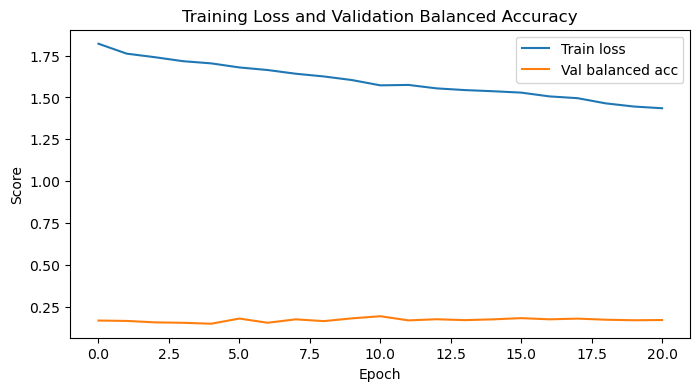

In [36]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_accs, label="Val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("Training Loss and Validation Balanced Accuracy")
plt.show()


Custom EEGNet – Test balanced accuracy: 0.183


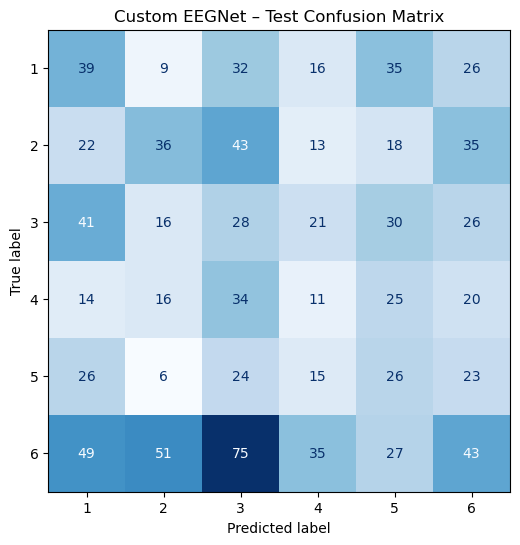

In [37]:
# 7. Final Evaluation ─ Custom EEGNet on Test Set
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1) Nome da variável com o melhor estado
#    No loop de treino chamamos de `best_model_state`, não `best_model_state_custom`
model.load_state_dict(best_model_state_custom)

# 2) Avaliação no split de teste
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

test_bal_acc = balanced_accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)      # both arrays são 0-based

print(f"Custom EEGNet – Test balanced accuracy: {test_bal_acc:.3f}")

# 3) Matriz de confusão
disp = ConfusionMatrixDisplay(cm, display_labels=[1, 2, 3, 4, 5, 6])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Custom EEGNet – Test Confusion Matrix")
plt.show()


## 8. EEGNetv4 Reference Model (Braindecode)

To benchmark our approach, we now replace the custom EEGNet implementation with the canonical EEGNetv4 model provided by the [Braindecode](https://braindecode.org/) library. This architecture is widely used and well-tested for EEG decoding tasks. We train and evaluate this model using the same splits, normalisation, and class weights as before, enabling a direct comparison of results.

In [38]:
# 8.1. Instantiate EEGNetv4 from Braindecode

model_bc = EEGNetv4(
    n_outputs=6,
    n_chans=n_channels,
    n_times=window_samples,
    final_conv_length='auto'
).to(device)

print("Braindecode EEGNetv4 model instantiated.")


Braindecode EEGNetv4 model instantiated.


In [39]:
# 8.2. Test forward pass

x_batch, y_batch = next(iter(train_loader))
x_batch = x_batch.to(device)
with torch.no_grad():
    out = model_bc(x_batch)
print(f"EEGNetv4 output shape: {out.shape}")
print(f"First 5 logits:\n{out[:5]}")


EEGNetv4 output shape: torch.Size([64, 6])
First 5 logits:
tensor([[ 0.4895, -0.7872, -0.8879, -0.6593, -0.4642, -1.4810],
        [-0.5292,  0.6139,  0.2756,  0.3769, -0.0835, -0.8460],
        [ 1.9290,  0.3958, -0.8089,  0.2317,  0.5367,  0.4923],
        [-0.5974, -0.0943,  1.5239, -0.8898, -1.6451,  0.0191],
        [ 1.4346,  0.1523,  0.7115, -0.8594, -0.2920,  0.7643]])


In [40]:
# 8.3. Training and validation for EEGNetv4

optimizer = optim.Adam(model_bc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss(weight=weights_tensor.to(device))

num_epochs = 100
patience = 10
best_val_acc = 0
epochs_no_improve = 0
train_losses = []
val_accs = []
best_model_state_ac = deepcopy(model_bc.state_dict())

for epoch in range(num_epochs):
    model_bc.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_bc(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    avg_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    val_acc = eval_model(model_bc, val_loader, device)
    val_accs.append(val_acc)
    scheduler.step(val_acc)

    print(f"Epoch {epoch+1}: Train loss={avg_loss:.4f} | Val bal-acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state_ac = deepcopy(model_bc.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best val bal-acc={best_val_acc:.3f}")
        break

model_bc.load_state_dict(best_model_state_ac)
print("Best EEGNetv4 model loaded from validation.")


Epoch 1: Train loss=1.9393 | Val bal-acc=0.189
Epoch 2: Train loss=1.8382 | Val bal-acc=0.170
Epoch 3: Train loss=1.8055 | Val bal-acc=0.167
Epoch 4: Train loss=1.7956 | Val bal-acc=0.167
Epoch 5: Train loss=1.7859 | Val bal-acc=0.177
Epoch 6: Train loss=1.7751 | Val bal-acc=0.182
Epoch 7: Train loss=1.7680 | Val bal-acc=0.191
Epoch 8: Train loss=1.7654 | Val bal-acc=0.188
Epoch 9: Train loss=1.7591 | Val bal-acc=0.200
Epoch 10: Train loss=1.7474 | Val bal-acc=0.200
Epoch 11: Train loss=1.7357 | Val bal-acc=0.187
Epoch 12: Train loss=1.7257 | Val bal-acc=0.183
Epoch 13: Train loss=1.7401 | Val bal-acc=0.186
Epoch 14: Train loss=1.7241 | Val bal-acc=0.189
Epoch 15: Train loss=1.7201 | Val bal-acc=0.189
Epoch 16: Train loss=1.7051 | Val bal-acc=0.188
Epoch 17: Train loss=1.6994 | Val bal-acc=0.187
Epoch 18: Train loss=1.6976 | Val bal-acc=0.186
Epoch 19: Train loss=1.6988 | Val bal-acc=0.189
Early stopping at epoch 19. Best val bal-acc=0.200
Best EEGNetv4 model loaded from validation.


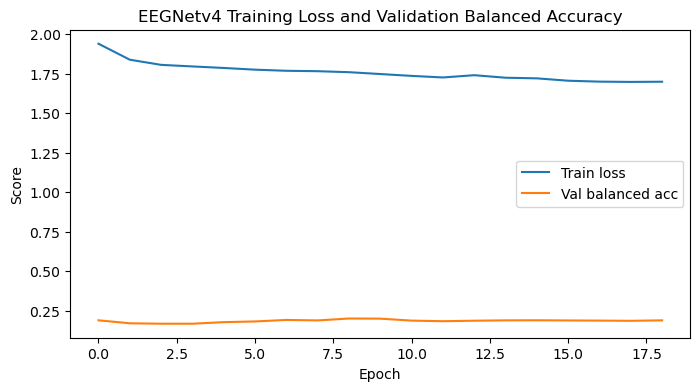

Final val bal-acc: 0.189


In [41]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_accs, label="Val balanced acc")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.title("EEGNetv4 Training Loss and Validation Balanced Accuracy")
plt.show()
print(f"Final val bal-acc: {val_accs[-1]:.3f}")


EEGNetv4 (Braindecode) - Test balanced accuracy: 0.200


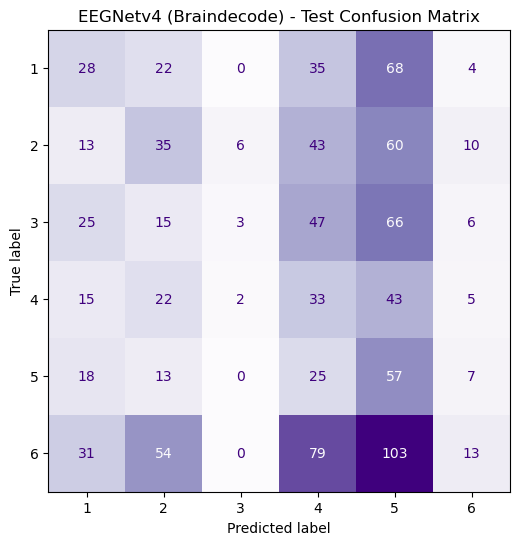

In [42]:
# 8. Final Evaluation: EEGNetv4 (Braindecode) on Test Set

# Ensure best model weights are loaded
model_bc.load_state_dict(best_model_state_ac)

# Collect predictions and labels
model_bc.eval()
all_preds_bc, all_labels_bc = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model_bc(xb)
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds_bc.extend(preds)
        all_labels_bc.extend(yb.cpu().numpy())

# Compute metrics
test_bal_acc_bc = balanced_accuracy_score(all_labels_bc, all_preds_bc)
cm_bc = confusion_matrix(all_labels_bc, all_preds_bc)

print(f"EEGNetv4 (Braindecode) - Test balanced accuracy: {test_bal_acc_bc:.3f}")

# Plot confusion matrix
disp_bc = ConfusionMatrixDisplay(cm_bc, display_labels=[1,2,3,4,5,6])
fig, ax = plt.subplots(figsize=(6,6))
disp_bc.plot(ax=ax, cmap="Purples", colorbar=False)
plt.title("EEGNetv4 (Braindecode) - Test Confusion Matrix")
plt.show()


## Função única para extrair A+B+C

In [43]:
import numpy as np
from scipy.signal import welch

def hjorth_params(signal):
    """
    signal : ndarray (n_samples,) - 1-D vector in volts
    returns: tuple(Activity, Mobility, Complexity)
    """
    # Activity = var(x)
    activity = np.var(signal, ddof=0)

    # First derivative
    dx = np.diff(signal, n=1)
    var_dx = np.var(dx, ddof=0)

    # Mobility = sqrt(var(dx) / var(x))
    mobility = np.sqrt(var_dx / (activity + 1e-12))

    # Second derivative
    ddx = np.diff(signal, n=2)
    var_ddx = np.var(ddx, ddof=0)

    # Complexity = Mobility(derivative) / Mobility
    mobility_dx = np.sqrt(var_ddx / (var_dx + 1e-12))
    complexity = mobility_dx / (mobility + 1e-12)

    return activity, mobility, complexity


def extract_feats(segment, sfreq,
                  bands=((1,4),(4,8),(8,13),(13,30),(30,50))):
    """
    segment : ndarray (n_channels, n_samples)
    sfreq   : sampling rate (Hz)
    bands   : tuples (fmin,fmax) - 5 bands by default
    return  : 1-D np.array with A+B+C for ALL channels
              len = n_channels * (5 + 5 + 3) = n_ch * 13
    """
    feats = []
    for ch_sig in segment:                       # loop through channels
        # ---------- A & B : power per band ----------
        f, pxx = welch(ch_sig, fs=sfreq, nperseg=256, noverlap=128)
        # total power 1-50 Hz
        total_paow = pxx[(f >= 1) & (f <= 50)].sum() + 1e-12

        for fmin, fmax in bands:
            band_pow = pxx[(f >= fmin) & (f < fmax)].sum() + 1e-12
            feats.append(np.log10(band_pow))           # A  (log-band-power)
            feats.append(band_pow / total_pow)         # B  (relative)

        # ---------- C : Hjorth ----------
        activity, mobility, complexity = hjorth_params(ch_sig)
        feats.extend([activity, mobility, complexity])

    return np.asarray(feats, dtype=np.float32)

In [47]:
def extract_feats(segment, sfreq, bands=[(0.5, 4), (4, 8), (8, 13), (13, 30)]):
    feats = []
    for ch_sig in segment:
        # ---------- A & B : log-band-power and relative band power ----------
        f, pxx = welch(ch_sig, sfreq, nperseg=sfreq*2)
        total_pow = np.sum(pxx) + 1e-12  # Adiciona um epsilon para evitar divisão por zero

        for fmin, fmax in bands:
            band_pow = pxx[(f >= fmin) & (f < fmax)].sum() + 1e-12
            feats.append(np.log10(band_pow))       # A (log band power)
            feats.append(band_pow / total_pow)     # B (relative band power)

        # ---------- C : Hjorth ----------
        activity, mobility, complexity = hjorth_params(ch_sig)
        feats += [activity, mobility, complexity]

    return feats


In [48]:
from tqdm import tqdm
sfreq = list(raws.values())[0].info["sfreq"]
feature_list, label_list, group_list = [], [], []


for row in tqdm(windows_df.itertuples(), total=len(windows_df)):
    seg = raws[row.block_id].get_data(
        picks=eeg_picks,
        start=int(row.start_sample),
        stop =int(row.start_sample)+window_samples
    )
    feats = extract_feats(seg, sfreq)
    feature_list.append(feats)
    label_list.append(row.label - 1)      # 0-based
    group_list.append(row.group)

X = np.vstack(feature_list)
y = np.array(label_list)
groups = np.array(group_list)


100%|██████████| 4216/4216 [00:05<00:00, 732.33it/s]


In [49]:
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import balanced_accuracy_score
import numpy as np, time

# ---------- split (mesmo esquema) ----------
gss = GroupShuffleSplit(test_size=0.20, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
gss_val = GroupShuffleSplit(test_size=0.25, n_splits=1, random_state=43)
train_idx, val_idx = next(gss_val.split(X[train_idx], y[train_idx], groups[train_idx]))

dtrain = lgb.Dataset(X[train_idx], label=y[train_idx])
dval   = lgb.Dataset(X[val_idx], label=y[val_idx])

params = dict(
    objective="multiclass",
    num_class=6,
    learning_rate=0.01,
    num_leaves=63,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    seed=42,
    verbose=-1           # silencia warnings
)

print("▶️  Treinando LightGBM…", flush=True)
start = time.time()

gbm = lgb.train(
    params,
    dtrain,
    num_boost_round=1200,
    valid_sets=[dval],
    valid_names=["val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=200, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

print(f"⏱️  {time.time()-start:.1f}s, melhor iter = {gbm.best_iteration}")

# ---------- métrica ----------
val_pred  = gbm.predict(X[val_idx]).argmax(1)
test_pred = gbm.predict(X[test_idx]).argmax(1)

val_bal_acc  = balanced_accuracy_score(y[val_idx],  val_pred)
test_bal_acc = balanced_accuracy_score(y[test_idx], test_pred)

print(f"\nValidation balanced accuracy: {val_bal_acc:.3f}")
print(f"Test      balanced accuracy: {test_bal_acc:.3f}")

▶️  Treinando LightGBM…
Training until validation scores don't improve for 200 rounds
[50]	val's multi_logloss: 1.7517
[100]	val's multi_logloss: 1.76525
[150]	val's multi_logloss: 1.78266
[200]	val's multi_logloss: 1.79969
Early stopping, best iteration is:
[17]	val's multi_logloss: 1.74135
⏱️  2.0s, melhor iter = 17

Validation balanced accuracy: 0.173
Test      balanced accuracy: 0.179


In [50]:
# janelas por classe em cada split
(pd.crosstab(windows_df["split"], windows_df["label"])
   .style.format(precision=0))


label,1,2,3,4,5,6
split,,,,,,
test,157,167,162,120,120,280
train,312,333,299,241,240,560
val,190,198,198,159,144,336


In [51]:
from sklearn.metrics import balanced_accuracy_score
val_blocks = np.unique(groups[val_idx])

for b in val_blocks:
    idx = np.where(groups[val_idx] == b)[0]
    bal = balanced_accuracy_score(y[val_idx][idx], val_pred[idx])
    print(f"Bloco {b:2d}  →  bal-acc = {bal:.2f}  ({idx.size} janelas)")


Bloco  6  →  bal-acc = 0.00  (12 janelas)
Bloco  7  →  bal-acc = 0.19  (202 janelas)
Bloco  8  →  bal-acc = 0.00  (8 janelas)
Bloco  9  →  bal-acc = 0.16  (158 janelas)
Bloco 10  →  bal-acc = 0.00  (28 janelas)
Bloco 12  →  bal-acc = 0.00  (4 janelas)
Bloco 13  →  bal-acc = 0.17  (197 janelas)
Bloco 16  →  bal-acc = 0.17  (180 janelas)


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [52]:
from sklearn.model_selection import StratifiedGroupKFold
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
for tr, va in sgkf.split(X, y, groups):
    booster = lgb.train(params, lgb.Dataset(X[tr], label=y[tr]),
                        num_boost_round=1200,
                        valid_sets=[lgb.Dataset(X[va], label=y[va])],
                        callbacks=[lgb.early_stopping(200, verbose=False)])
    scores.append(balanced_accuracy_score(y[va],
                                          booster.predict(X[va]).argmax(1)))
print("CV bal-acc  mean ± std :", np.mean(scores).round(3),
      "±", np.std(scores).round(3))


CV bal-acc  mean ± std : 0.188 ± 0.013


In [53]:
# --- 0. filtra blocos com ≥ 20 janelas ---
keep_blocks = windows_df.groupby("block_id").filter(lambda g: len(g) >= 20).block_id.unique()
mask = np.isin(groups, keep_blocks)

X_filt, y_filt, g_filt = X[mask], y[mask], groups[mask]

# --- 1. novo split / CV ---
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
scores = []
for tr, va in sgkf.split(X_filt, y_filt, g_filt):
    booster = lgb.train(params, lgb.Dataset(X_filt[tr], y_filt[tr]),
                        num_boost_round=1200,
                        valid_sets=[lgb.Dataset(X_filt[va], y_filt[va])],
                        callbacks=[lgb.early_stopping(200, verbose=False)])
    scores.append(balanced_accuracy_score(y_filt[va],
                                          booster.predict(X_filt[va]).argmax(1)))
print("CV bal-acc :", np.mean(scores).round(3), "±", np.std(scores).round(3))


CV bal-acc : 0.188 ± 0.013


In [54]:
# ╔════════════════════════════════════════════════════════════╗
# ║  Feature layer D  –  Wavelet packet energy (6 nós)         ║
# ╚════════════════════════════════════════════════════════════╝
import pywt, numpy as np
from tqdm import tqdm

def wpe_channel(sig, wavelet="db4", level=6):
    """Energia em 6 nós definidos; retorna shape (6,)"""
    wp = pywt.WaveletPacket(sig, wavelet, maxlevel=level, mode="symmetric")
    # nós aproximando bandas ~δ,θ,α,β,γ; escolha fixa:
    paths = ("aaa", "aad", "ada", "add", "daa", "dad")
    return np.array([wp[p].data for p in paths], dtype=np.float32).var(axis=1)

def extract_D_segment(seg):                # seg: C × T
    return np.hstack([wpe_channel(ch) for ch in seg])   # (C·6,)

print("⚙️  Extraindo Wavelet-packet energy…")
X_D = []
for row in tqdm(windows_df.itertuples(), total=len(windows_df)):
    seg = raws[row.block_id].get_data(
        picks=eeg_picks,
        start=int(row.start_sample),
        stop =int(row.start_sample)+window_samples
    )
    X_D.append(extract_D_segment(seg))

X_D = np.vstack(X_D)           # (N, C·6)
print("Shape D :", X_D.shape)

# -------- empilha A+B+C+D --------
X_full = np.hstack([X, X_D])   # (N, 13*12 + 13*6) = (N, 234)
print("Shape total:", X_full.shape)

# ╔════════════ 5-fold com A+B+C+D ═══════════╗
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
scores = []
for tr, va in sgkf.split(X_full, y, groups):
    booster = lgb.train(params,
                        lgb.Dataset(X_full[tr], label=y[tr]),
                        num_boost_round=1500,
                        valid_sets=[lgb.Dataset(X_full[va], label=y[va])],
                        callbacks=[lgb.early_stopping(200, verbose=False)])
    preds = booster.predict(X_full[va]).argmax(1)
    scores.append(balanced_accuracy_score(y[va], preds))

print("\nCV bal-acc  (A+B+C+D):", np.mean(scores).round(3),
      "±", np.std(scores).round(3))


⚙️  Extraindo Wavelet-packet energy…


100%|██████████| 4216/4216 [00:04<00:00, 1024.95it/s]


Shape D : (4216, 84)
Shape total: (4216, 238)

CV bal-acc  (A+B+C+D): 0.189 ± 0.017


In [55]:
# --- nova extração D all-level-5 ------------------------------------
def extract_D_lvl5(seg, wavelet="sym5"):
    wp = pywt.WaveletPacket(seg, wavelet, maxlevel=5, mode="symmetric")
    paths = [n.path for n in wp.get_level(5, 'freq')]   # 32 nós
    return np.hstack([wp[p].data.var() for p in paths]) # (32,)

X_D2 = np.vstack([np.hstack([extract_D_lvl5(ch) for ch in
                             raws[row.block_id].get_data(picks=eeg_picks,
                             start=row.start_sample,
                             stop=row.start_sample+window_samples)])
                  for row in windows_df.itertuples()])

X_full2 = np.hstack([X, X_D2])           # 156 + 32·12 = 540 cols

# -------- LGB params ------------
params.update({
    "learning_rate": 0.01,
    "num_leaves": 63,
    "max_depth": 6,
    "min_data_in_leaf": 15,
    "lambda_l2": 0.1,
})

# -------- 5-fold ------------
scores=[]
for tr,va in StratifiedGroupKFold(5,True,42).split(X_full2,y,groups):
    booster = lgb.train(params,lgb.Dataset(X_full2[tr],y[tr]),
                        2000,[lgb.Dataset(X_full2[va],y[va])],
                        callbacks=[lgb.early_stopping(200,verbose=False)])
    scores.append(balanced_accuracy_score(y[va],
                booster.predict(X_full2[va]).argmax(1)))
print("CV bal-acc (A+B+C+D2):", np.mean(scores).round(3),
      "±", np.std(scores).round(3))


CV bal-acc (A+B+C+D2): 0.185 ± 0.015
